# Duckweed Vision Pipeline — Step by Step

Acquire an image from the hardware camera via `MachineSession`, then test each vision ingredient in isolation.

## 1 — Imports

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
sys.path.append("../")
sys.path.append("../../../")
sys.path.append("../../../../")


from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Duckweed_tracker.ingredients.float_detection import get_float_points
from science_jubilee.Vision.Duckweed_tracker.ingredients.segmentation import get_img_contour
from science_jubilee.Vision.Duckweed_tracker.ingredients.isolated_duckweed import detect_isolated_duckweed
from science_jubilee.Vision.Duckweed_tracker.ingredients.pose_estimation import estimate_float_pose
from science_jubilee.Vision.Duckweed_tracker.ingredients.localization import get_lens_position

def show(img, title=""):
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

C:\Users\Alienor\Documents\Projects\Jubilee\.pixi\envs\default\Lib\site-packages\sacred\dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2 — Session + Image Acquisition

Edit `.env.hardware` to point `JUBILEE_EXPERIMENT_DIR` at your experiment folder.

In [3]:
import time

session = MachineSession.from_env(".env.hardware")
cam = session.camera

# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 220.0, 80.0, 200.0
cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)


#### Open the camera tab (octoprint) to perform autofocus

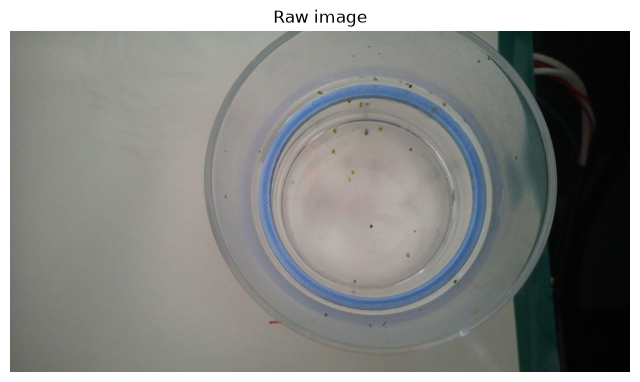

In [4]:

img = cam.get_image()
show(img, "Raw image")

## 3 — Float Detection

Centre (px): (1122, 513)
Radius (px): 352.7342224121094
Cardinal points:
 [[ 769.6223   513.43494]
 [1122.3566   160.70071]
 [1475.0908   513.43494]
 [1122.3566   866.1692 ]]


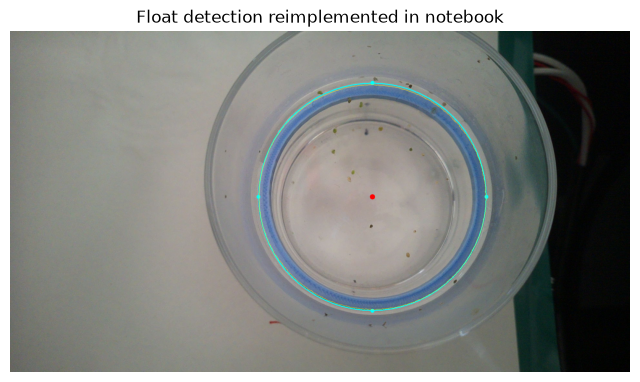

In [7]:


threshold_blue = 170
min_area_px = 250
min_circularity = 0.7

float_det = get_float_points(
    img,
    threshold_blue=threshold_blue,
    min_area_px=min_area_px,
    min_circularity=min_circularity,
 )
print("Centre (px):", float_det.center_px)
print("Radius (px):", float_det.radius_px)
print("Cardinal points:\n", float_det.points)

vis = img.copy()
for pt in float_det.points:
    cv2.circle(vis, (int(pt[0]), int(pt[1])), 6, (0, 255, 255), -1)
cv2.circle(vis, float_det.center_px, int(float_det.radius_px), (0, 255, 255), 2)
cv2.drawContours(vis, [float_det.contour], -1, (255, 255, 0), 1)
cv2.circle(vis, float_det.center_px, 8, (255, 0, 0), -1)
show(vis, "Float detection reimplemented in notebook")

## 4 — Segmentation (ExG contours)

66 valid contours found


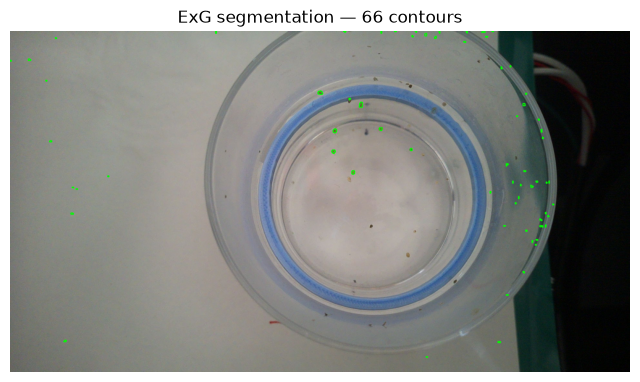

In [8]:
min_area_px=10
max_area_px=300
min_circularity=0.5
threshold_green = 150

contours = get_img_contour(img, min_area_px=min_area_px, max_area_px=max_area_px, min_circularity=min_circularity, threshold_green = threshold_green)
print(f"{len(contours)} valid contours found")

vis = img.copy()
cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)
show(vis, f"ExG segmentation — {len(contours)} contours")

## 5 — Isolated duckweed detection

Target pixel: (1242, 366)
Contours inside float: 7


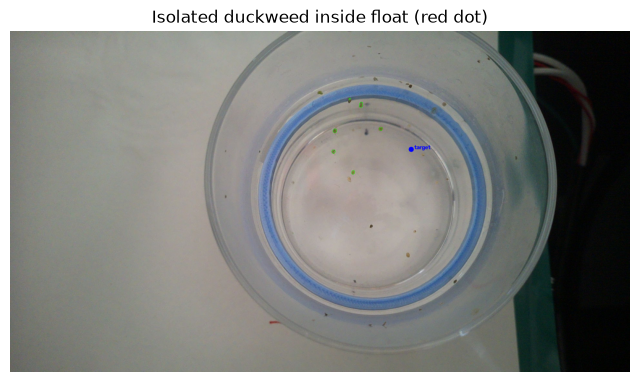

In [9]:
max_distance_ratio = 0.8
target_px, contours_in_float = detect_isolated_duckweed(
    img,
    float_points=float_det.points,
    valid_contours=contours,
    max_distance_ratio=max_distance_ratio,
    float_contour=float_det.contour,
    return_filtered_contours=True,
 )
print("Target pixel:", target_px)
print(f"Contours inside float: {len(contours_in_float)}")

vis = img.copy()
cv2.drawContours(vis, contours_in_float, -1, (0, 255, 0), 1)
if target_px:
    cv2.circle(vis, target_px, 8, (0, 0, 255), -1)
    cv2.putText(vis, "target", (target_px[0]+10, target_px[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
show(vis, "Isolated duckweed inside float (red dot)")

## 6 — Pose estimation (float depth via PnP)

In [10]:
tvec = estimate_float_pose(cam, float_det.points, float_radius_mm = 37.5)
water_level = tvec[2]
print(f"Float 3D (camera frame): X={tvec[0]:.1f}  Y={tvec[1]:.1f}  Z={tvec[2]:.1f} mm")
print(f"Water level (Z): {water_level:.1f} mm")

Float 3D (camera frame): X=16.9  Y=-2.8  Z=156.7 mm
Water level (Z): 156.7 mm


## 7 — 3D localization of the duckweed

In [11]:
if target_px is None:
    print("No target detected — cannot localise.")
else:
    duckweed_3d = get_lens_position(cam, target_px, water_level)
    print(f"Duckweed 3D (camera frame): X={duckweed_3d[0]:.2f}  Y={duckweed_3d[1]:.2f}  Z={duckweed_3d[2]:.2f} mm")

    ox, oy, oz = cam.offset
    x_machine = X_DEPART + ox + duckweed_3d[0]
    y_machine = Y_DEPART + oy - duckweed_3d[1]
    z_machine = Z_DEPART + oz - duckweed_3d[2]
    print(f"Machine frame target: X={x_machine:.2f}  Y={y_machine:.2f}  Z={z_machine:.2f}")

Duckweed 3D (camera frame): X=30.03  Y=-18.34  Z=156.70 mm
Machine frame target: X=250.03  Y=78.34  Z=43.30
